<a href="https://colab.research.google.com/github/melia1702/Pertemuan-keempat/blob/main/Latihan_3_Pertemuan_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

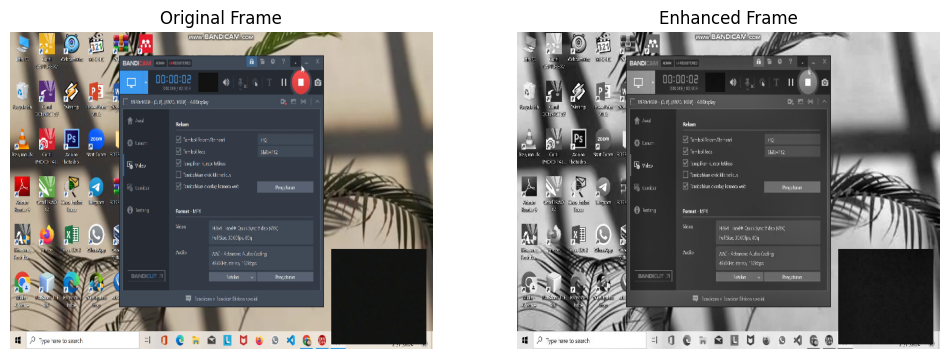

=== Proses Enhancement Selesai ===


In [1]:
# ============================================
# LATIHAN 3: REAL-TIME VIDEO ENHANCEMENT
# ============================================

# 1. Import Library
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# ============================================
# 2. Upload Video
# ============================================

print("Upload video untuk diproses")
uploaded = files.upload()

video_path = list(uploaded.keys())[0]


# ============================================
# 3. Class RealTimeEnhancement
# ============================================

class RealTimeEnhancement:

    def __init__(self, target_fps=30):
        self.target_fps = target_fps
        self.history_buffer = []
        self.buffer_size = 5   # batas memory

    def enhance_frame(self, frame, enhancement_type='adaptive'):

        # Convert ke grayscale agar komputasi ringan
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # ======================================
        # 1. Enhancement dengan constraint cepat
        # ======================================

        if enhancement_type == 'adaptive':

            # CLAHE (cepat dan cocok real-time)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            enhanced = clahe.apply(gray)

        elif enhancement_type == 'sharpen':

            kernel = np.array([[0,-1,0],
                               [-1,5,-1],
                               [0,-1,0]])
            enhanced = cv2.filter2D(gray,-1,kernel)

        elif enhancement_type == 'denoise':

            enhanced = cv2.GaussianBlur(gray,(5,5),0)

        else:
            enhanced = gray

        # ======================================
        # 2. Temporal Consistency
        # ======================================

        self.history_buffer.append(enhanced)

        if len(self.history_buffer) > self.buffer_size:
            self.history_buffer.pop(0)

        # rata-rata frame untuk mengurangi flicker
        temporal_avg = np.mean(self.history_buffer, axis=0).astype(np.uint8)


        # ======================================
        # 3. Memory limitation
        # ======================================
        # buffer dibatasi agar tidak boros RAM

        return temporal_avg


# ============================================
# 4. Membaca Video
# ============================================

cap = cv2.VideoCapture(video_path)

enhancer = RealTimeEnhancement(target_fps=30)

frame_count = 0

print("Memproses video...")

while cap.isOpened():

    ret, frame = cap.read()

    if not ret:
        break

    # resize agar lebih ringan
    frame = cv2.resize(frame,(640,480))

    # enhancement frame
    enhanced_frame = enhancer.enhance_frame(frame,'adaptive')


    # ======================================
    # Tampilkan hasil
    # ======================================

    clear_output(wait=True)

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.title("Original Frame")
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.title("Enhanced Frame")
    plt.imshow(enhanced_frame, cmap='gray')
    plt.axis('off')

    plt.show()


    frame_count += 1

    # batasi frame agar tidak terlalu lama
    if frame_count > 60:
        break


cap.release()

print("=== Proses Enhancement Selesai ===")